# Kadai 1
Logistic map, Hénon map, Lorenz attractor — time series, cobweb, invariant density, Fourier spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Logistic Map
$$x_{n+1} = a x_n (1 - x_n)$$
for $a \in \{3.58, 3.67, 3.86, 4.0\}$

In [2]:
def logistic(a, x0=0.5, N=5000, transient=1000):
    x = np.empty(N + transient)
    x[0] = x0
    for n in range(N + transient - 1):
        x[n+1] = a * x[n] * (1 - x[n])
    return x[transient:]

a_vals = [3.58, 3.67, 3.86, 4.0]
series = {a: logistic(a) for a in a_vals}

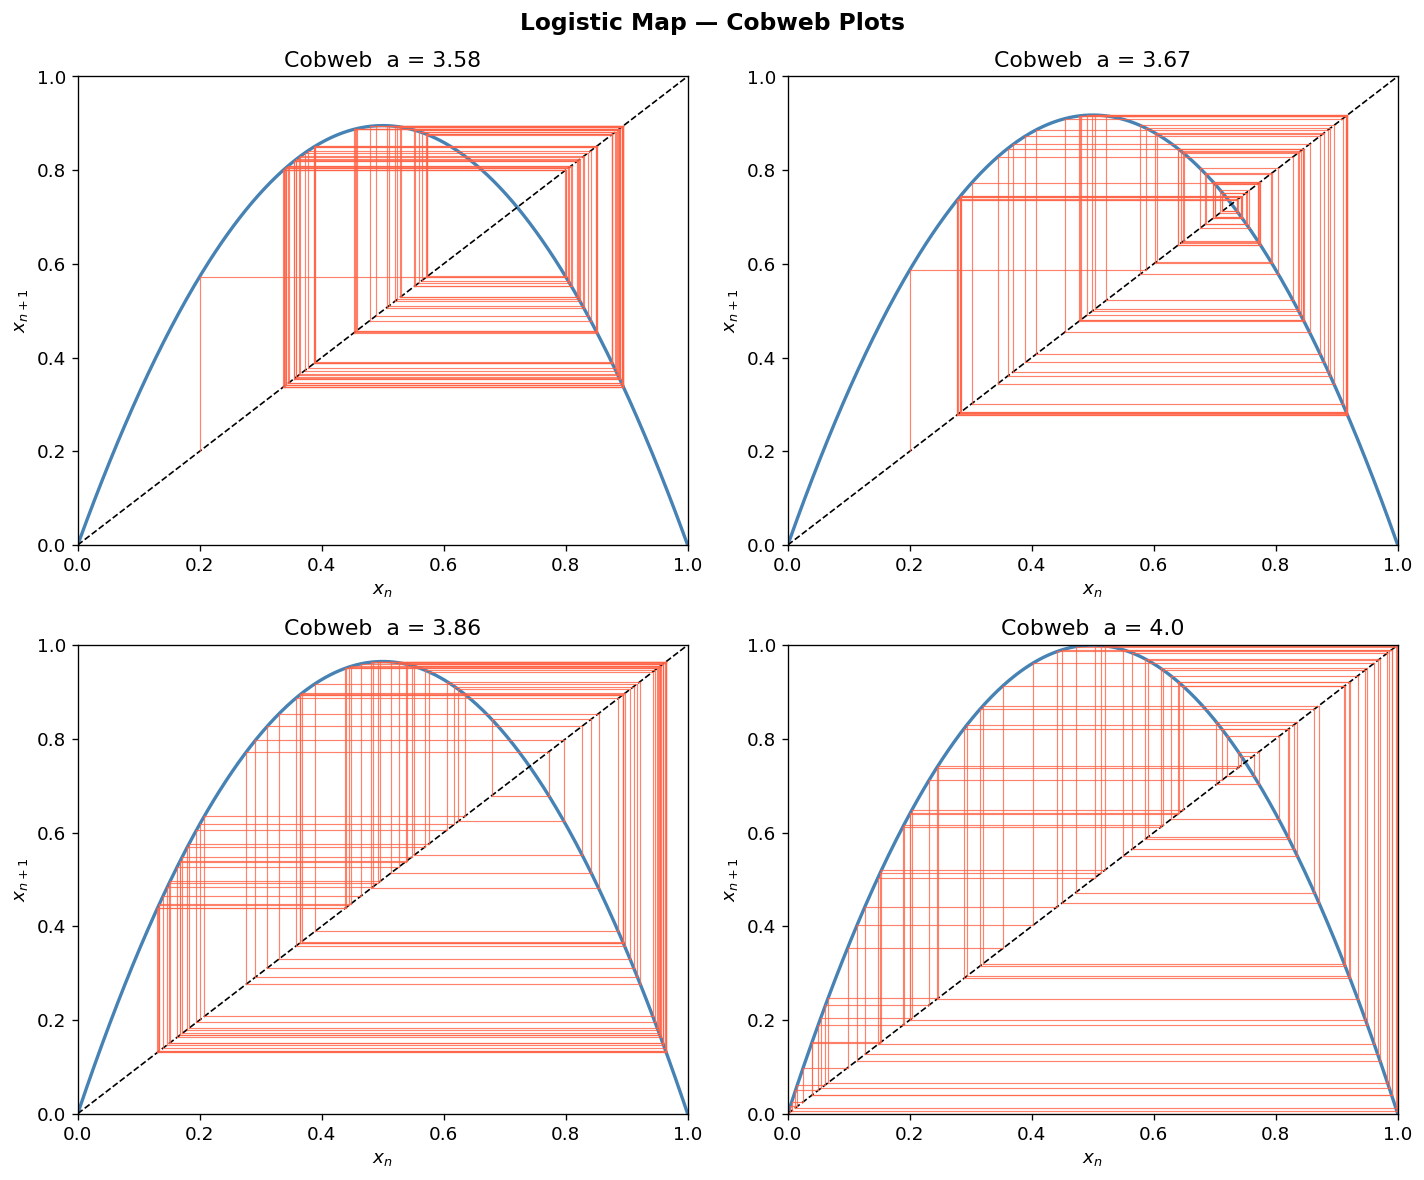

In [3]:
# --- Cobweb plots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, a in enumerate(a_vals):
    ax = axes[idx]
    xs = np.linspace(0, 1, 400)
    ax.plot(xs, a * xs * (1 - xs), 'steelblue', lw=2, label=f'f(x)')
    ax.plot(xs, xs, 'k--', lw=1)

    # cobweb starting from x0
    x = 0.2
    for _ in range(80):
        fx = a * x * (1 - x)
        ax.plot([x, x], [x, fx], 'tomato', lw=0.7, alpha=0.8)
        ax.plot([x, fx], [fx, fx], 'tomato', lw=0.7, alpha=0.8)
        x = fx

    ax.set_title(f'Cobweb  a = {a}')
    ax.set_xlabel('$x_n$'); ax.set_ylabel('$x_{n+1}$')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Logistic Map — Cobweb Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

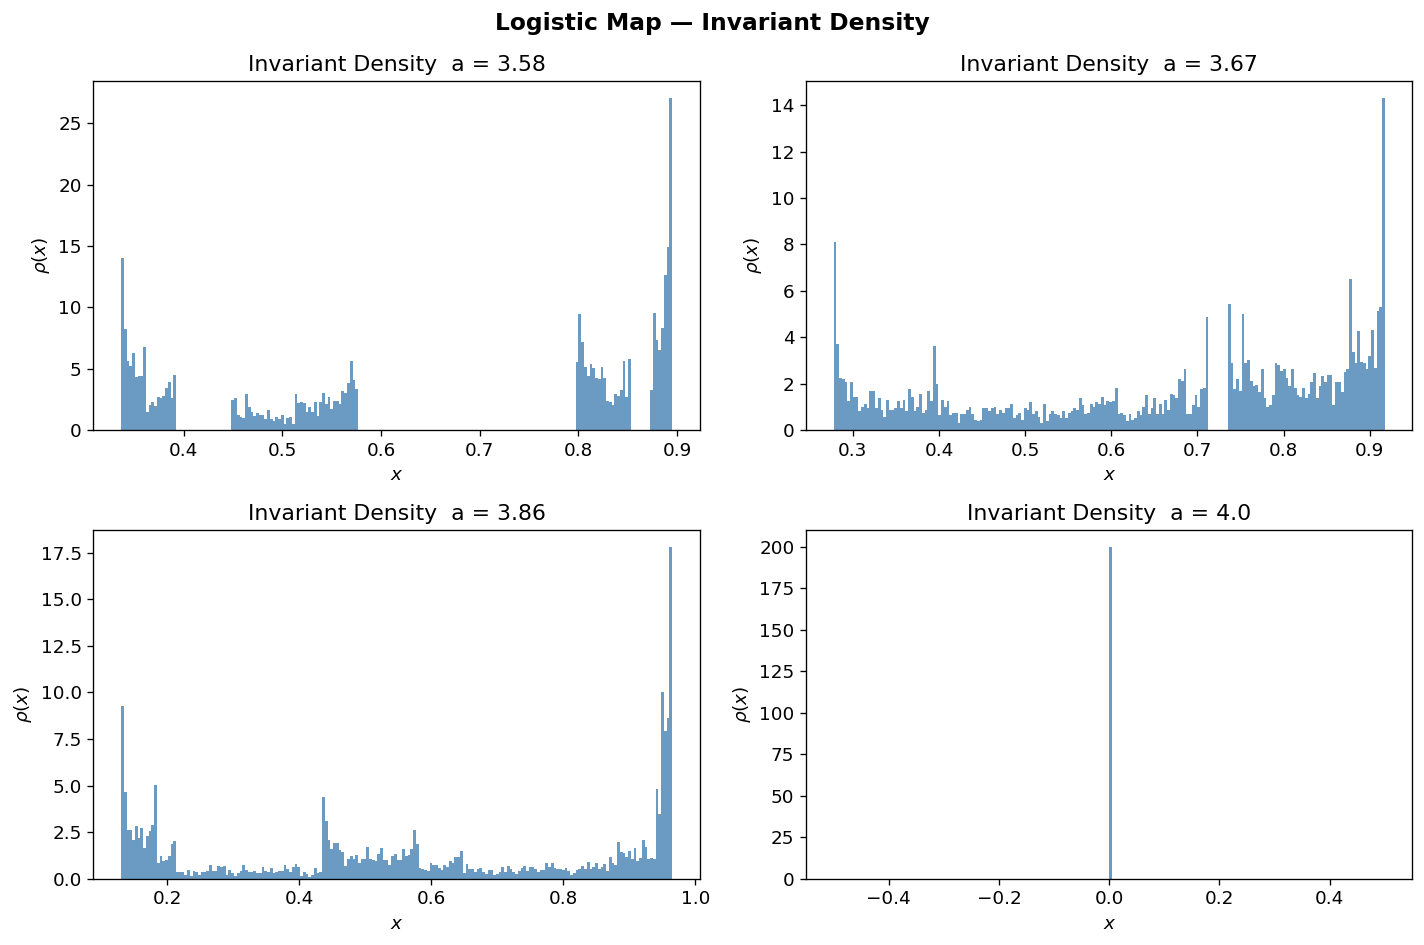

In [4]:
# --- Invariant density (histogram) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, a in enumerate(a_vals):
    ax = axes[idx]
    ax.hist(series[a], bins=200, density=True, color='steelblue', alpha=0.8)
    ax.set_title(f'Invariant Density  a = {a}')
    ax.set_xlabel('$x$'); ax.set_ylabel('$\\rho(x)$')

plt.suptitle('Logistic Map — Invariant Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Kazi\AppData\Local\Temp\ipykernel_2492\2467786849.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


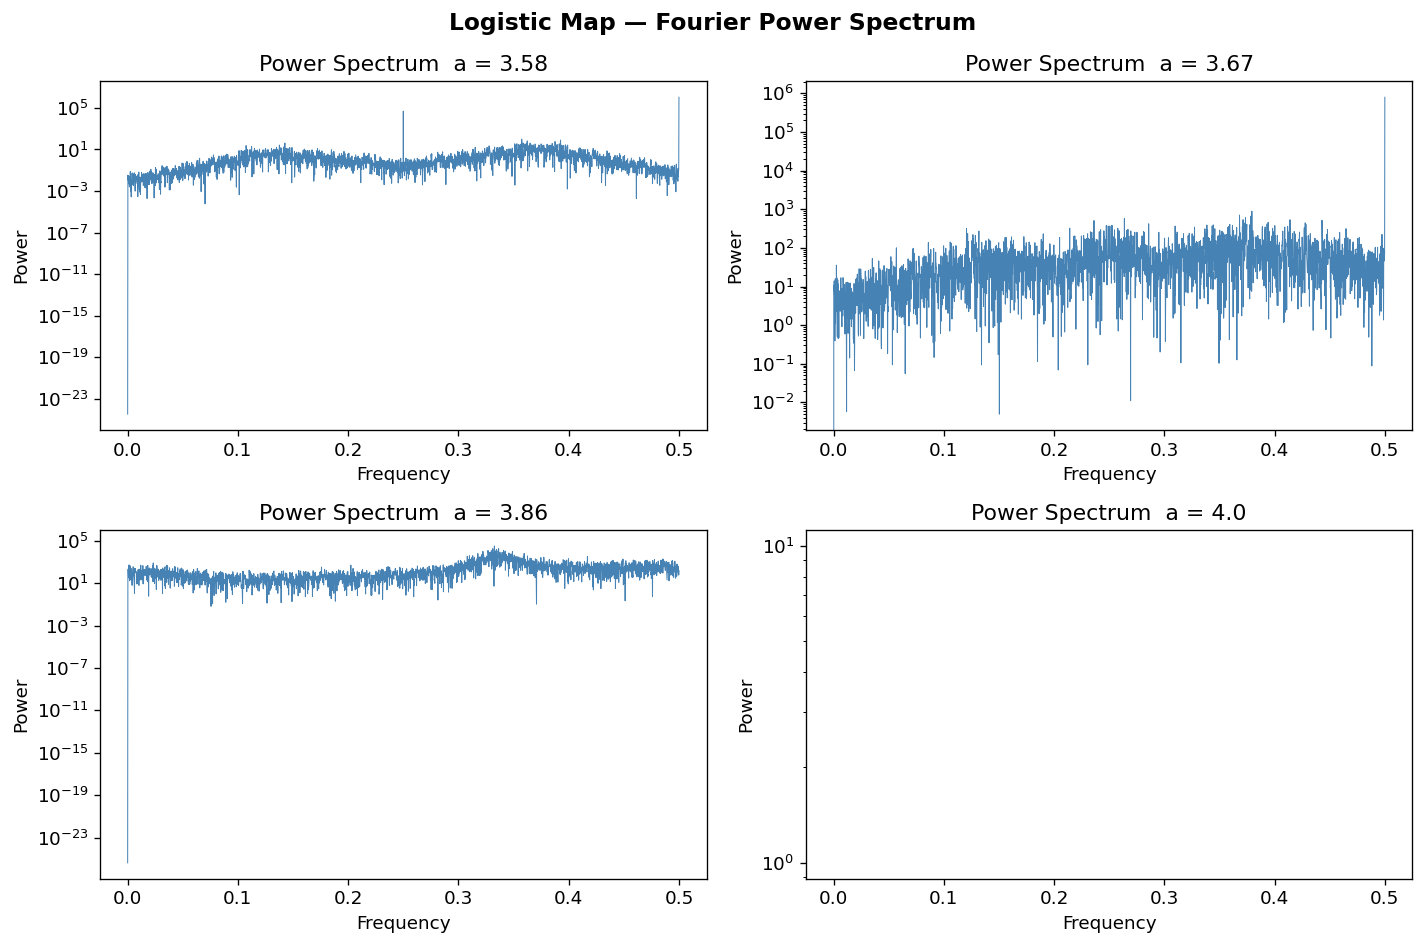

In [5]:
# --- Fourier spectrum ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, a in enumerate(a_vals):
    ax = axes[idx]
    N = len(series[a])
    freqs = np.fft.rfftfreq(N)
    power = np.abs(np.fft.rfft(series[a] - series[a].mean()))**2
    ax.semilogy(freqs, power, lw=0.6, color='steelblue')
    ax.set_title(f'Power Spectrum  a = {a}')
    ax.set_xlabel('Frequency'); ax.set_ylabel('Power')

plt.suptitle('Logistic Map — Fourier Power Spectrum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Hénon Map
$$x_{n+1} = 1 - ax_n^2 + y_n, \quad y_{n+1} = bx_n$$
$a=1.4,\; b=0.3$

In [6]:
def henon(a=1.4, b=0.3, N=50000, transient=1000):
    x, y = 0.1, 0.1
    xs, ys = [], []
    for n in range(N + transient):
        xn = 1 - a*x**2 + y
        yn = b*x
        x, y = xn, yn
        if n >= transient:
            xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

hx, hy = henon()

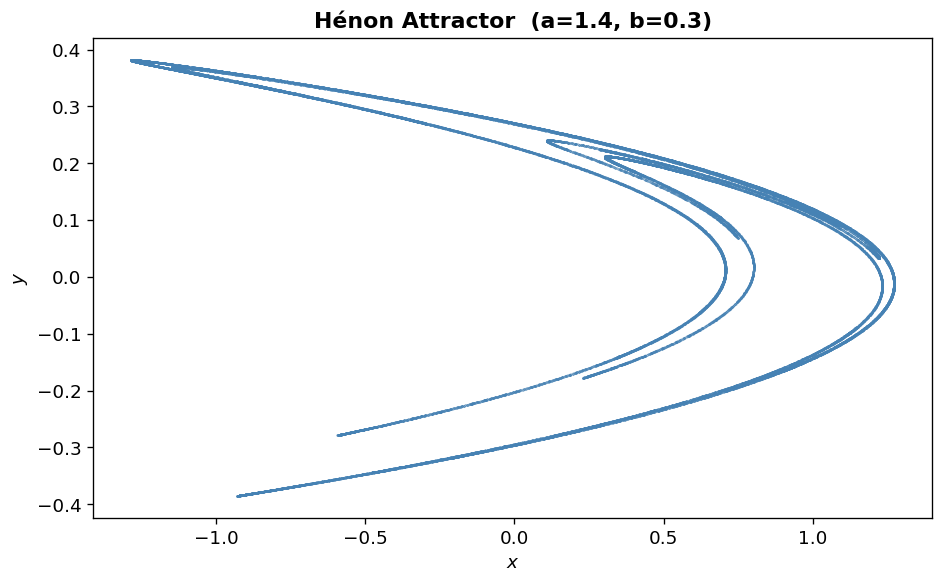

In [7]:
# Attractor plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hx, hy, s=0.1, c='steelblue', alpha=0.5)
ax.set_title('Hénon Attractor  (a=1.4, b=0.3)', fontweight='bold')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

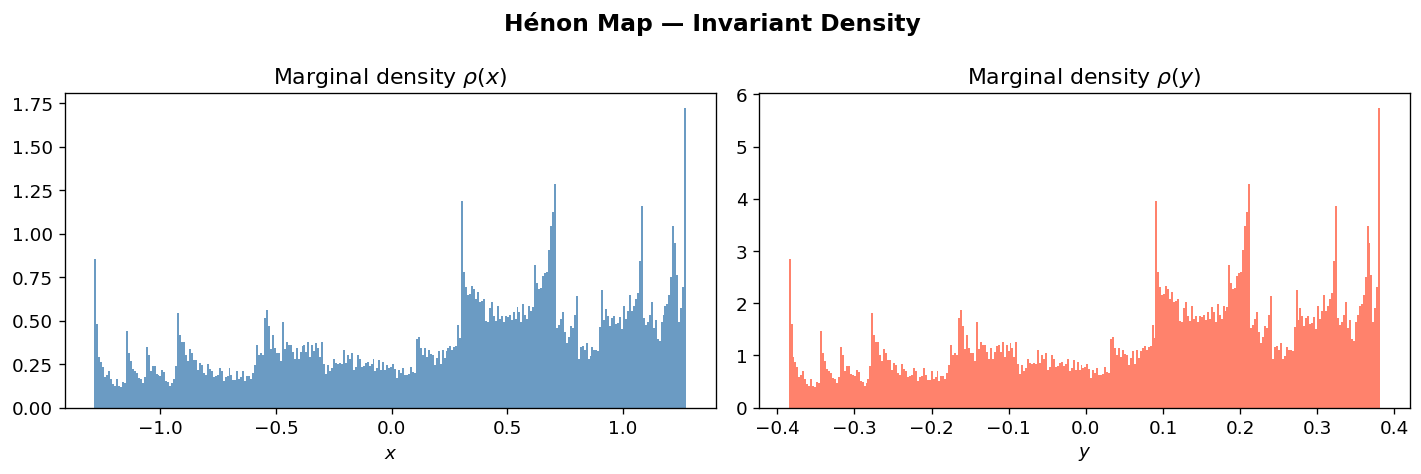

In [8]:
# Invariant density — 2D histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(hx, bins=300, density=True, color='steelblue', alpha=0.8)
axes[0].set_title('Marginal density $\\rho(x)$')
axes[0].set_xlabel('$x$')

axes[1].hist(hy, bins=300, density=True, color='tomato', alpha=0.8)
axes[1].set_title('Marginal density $\\rho(y)$')
axes[1].set_xlabel('$y$')

plt.suptitle('Hénon Map — Invariant Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

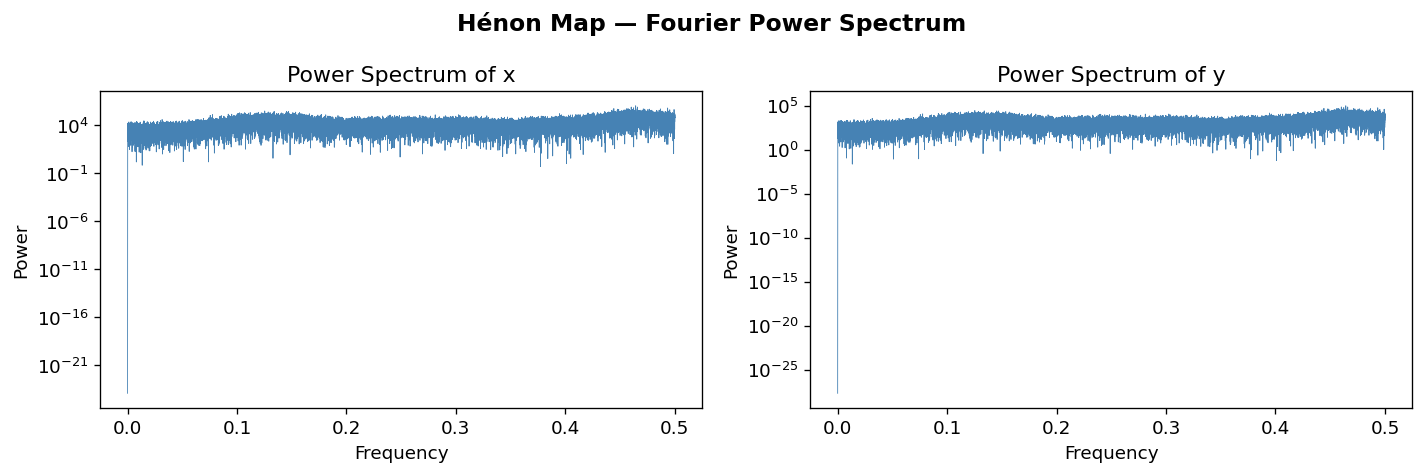

In [9]:
# Fourier spectrum of x-series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sig, label in zip(axes, [hx, hy], ['x', 'y']):
    N = len(sig)
    freqs = np.fft.rfftfreq(N)
    power = np.abs(np.fft.rfft(sig - sig.mean()))**2
    ax.semilogy(freqs, power, lw=0.5, color='steelblue')
    ax.set_title(f'Power Spectrum of {label}')
    ax.set_xlabel('Frequency'); ax.set_ylabel('Power')

plt.suptitle('Hénon Map — Fourier Power Spectrum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Lorenz Attractor
$$\dot{x}=\sigma(y-x),\quad \dot{y}=x(r-z)-y,\quad \dot{z}=xy-bz$$
$\sigma=10,\; r=28,\; b=8/3$

In [10]:
def lorenz_rhs(t, state, sigma=10, r=28, b=8/3):
    x, y, z = state
    return [sigma*(y - x), x*(r - z) - y, x*y - b*z]

sol = solve_ivp(lorenz_rhs, [0, 60], [1, 1, 1], max_step=0.01, dense_output=False)
t = sol.t; x, y, z = sol.y

# drop transient
mask = t > 5
x, y, z = x[mask], y[mask], z[mask]

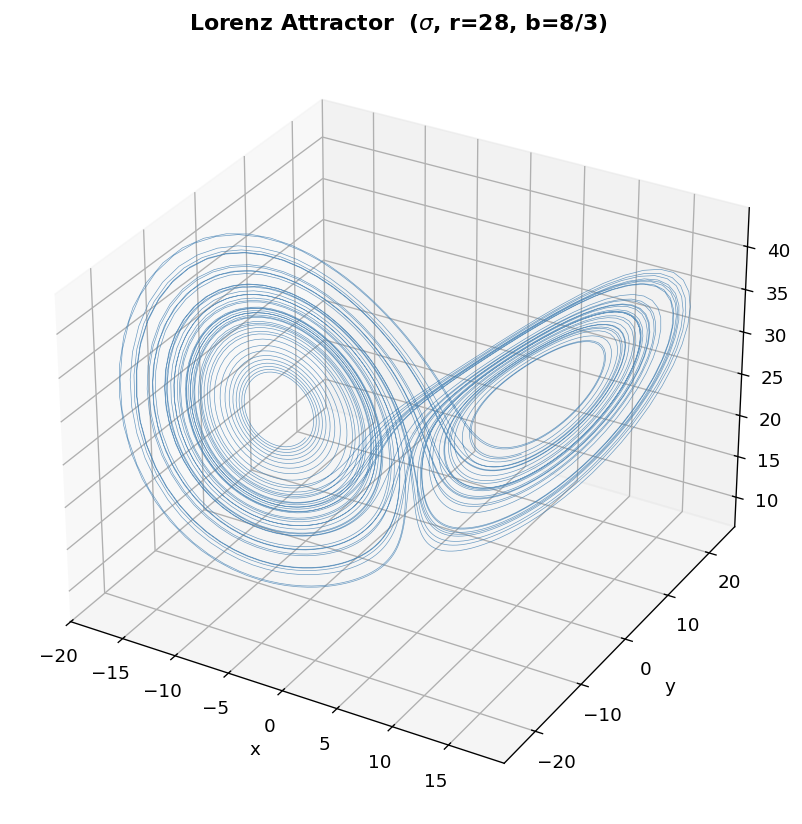

In [12]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.4, color='steelblue', alpha=0.8)
ax.set_title('Lorenz Attractor  ($\\sigma$, r=28, b=8/3)', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()